In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from pysr import PySRRegressor
import matplotlib.pyplot as plt

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
df = pd.read_excel("./datset.xlsx")
df = df.drop("Autor", axis=1)
X = df.drop("w_exp (mm)", axis=1)
y = df["w_exp (mm)"]

In [3]:
X = X.rename(columns=lambda c: c.encode("ascii", "ignore").decode("ascii"))
X.columns = [c.replace("(", "").replace(")", "").replace(" ", "_") for c in X.columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [4]:
model = PySRRegressor(
    parsimony=0.015,
    maxsize=20,
    maxdepth=6,
    population_size=50,
    ncycles_per_iteration=4000,
    niterations=1500,
    adaptive_parsimony_scaling=100.0,
    deterministic=False,
    parallelism='multithreading',
    progress=True,
    should_optimize_constants=True,
    optimizer_algorithm="BFGS",
    optimizer_nrestarts=5,
    binary_operators=["+", "-", "*", "/", "pow"],
    unary_operators=["sin", "cos", "exp", "log", "sqrt", "square", "abs"],
    constraints={"pow": (-1, 1)},
    weight_optimize=0.005,
)

model.fit(X_train, y_train)

/home/andre/programing/lamfo/ic_andre_rimes/env/lib/python3.10/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 5.730e+05
Progress: 168 / 46500 total iterations (0.361%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.474e-02  0.000e+00  y = 0.26695
3           1.204e-02  1.015e-01  y = Tenso_na_armadura_menos_tension_stiffening_MPa * 0.000...
                                      95397
4           1.189e-02  1.253e-02  y = sin(Tenso_na_armadura_menos_tension_stiffening_MPa * 0...
                                      .00097864)
5           1.024e-02  1.493e-01  y = (0.00060318 * Tenso_na_armadura_menos_tension_stiffeni...
                                      ng_MPa) - -0.10863
7           9.135e-03  5.704e-02  y = 0.00071804 * ((Distncia_ao_centro_de_gravidade_da_arma...
                                      dura__mm + Tenso_na_armadura_menos_tension_st

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.474e-02  0.000e+00  y = 0.26695
3           1.204e-02  1.015e-01  y = Tenso_na_armadura_menos_tension_stiffening_MPa * 0.000...
                                      95397
4           1.087e-02  1.015e-01  y = 0.016919 * sqrt(Tenso_na_armadura_menos_tension_stiffe...
                                      ning_MPa)
5           8.804e-03  2.112e-01  y = (Distncia_ao_centro_de_gravidade_da_armadura__mm * 2.3...
                                      563e-05) * Tenso_na_armadura_menos_tension_stiffening_MPa
6           8.791e-03  1.432e-03  y = sin(Tenso_na_armadura_menos_tension_stiffening_MPa * (...
                                      Distncia_ao_centro_de_gravidade_da_armadura__mm * 2.4064e-...
                                      05))
7           7.501e-03  1.587e-01  y = (Tenso_na_armadura_menos_tension_stiffening_MPa + Espa...


,model_selection,'best'
,binary_operators,"['+', '-', ...]"
,unary_operators,"['sin', 'cos', ...]"
,expression_spec,None
,niterations,1500
,populations,31
,population_size,50
,max_evals,None
,maxsize,20
,maxdepth,6
,warmup_maxsize_by,None


  - outputs/20250925_214735_qdg0Kg/hall_of_fame.csv


In [5]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

best_eq = model.get_best()
best_equation = best_eq['equation']

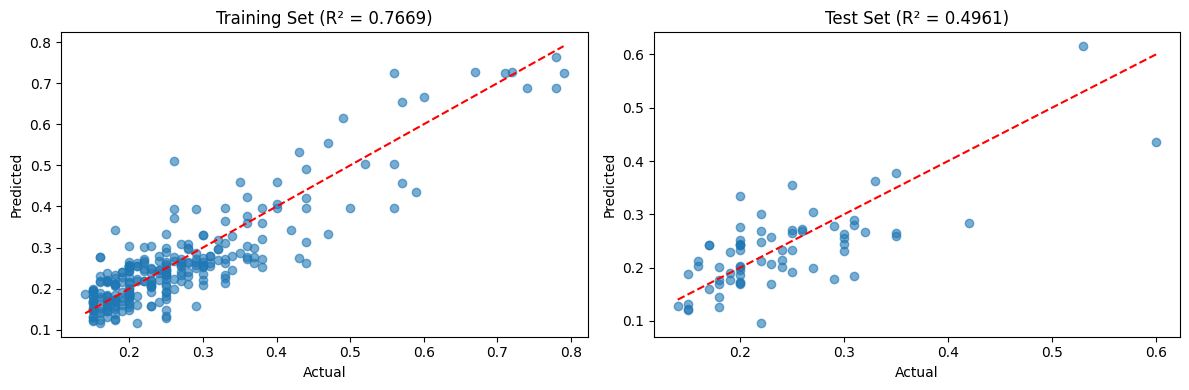

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(y_train, y_pred_train, alpha=0.6)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f'Training Set (R² = {r2_train:.4f})')

ax2.scatter(y_test, y_pred_test, alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'Test Set (R² = {r2_test:.4f})')

plt.tight_layout()
plt.show()

In [7]:
best_eq = model.get_best()
print(f"Best equation: {best_eq['equation']}")
print(f"Complexity: {best_eq['complexity']} nodes")

print("\nFull equations found:")
print(model.equations_[['complexity', 'loss', 'score', 'equation']])

Best equation: (1.6349633e-5 * (Tenso_na_armadura_menos_tension_stiffening_MPa + Espaamento_entre_as_barras_mm)) * (exp(Nmero_de_barras_em_uma_camada * sin(Cobrimento_mm)) + Distncia_ao_centro_de_gravidade_da_armadura__mm)
Complexity: 13 nodes

Full equations found:
    complexity      loss     score  \
0            1  0.014745  0.000000   
1            3  0.012037  0.101469   
2            4  0.010874  0.101543   
3            5  0.008804  0.211190   
4            6  0.008791  0.001432   
5            7  0.007501  0.158695   
6            8  0.005706  0.273624   
7            9  0.005101  0.111936   
8           10  0.005004  0.019357   
9           11  0.004263  0.160118   
10          12  0.003912  0.086021   
11          13  0.003437  0.129300   
12          14  0.003437  0.000004   
13          15  0.003141  0.090276   
14          17  0.002911  0.037984   
15          18  0.002823  0.030610   
16          20  0.002680  0.025999   

                                             equ

In [8]:
import sympy as sp
from IPython.display import display, Latex

equation_sympy = model.sympy()
equation_latex = sp.latex(equation_sympy)

table_latex = f"""
\\begin{{array}}{{|l|c|}}
\\hline
\\textbf{{Metric}} & \\textbf{{Value}} \\\\
\\hline
\\text{{Equation}} & {equation_latex} \\\\
\\hline
R^2 \\text{{ (Train)}} & {r2_train:.4f} \\\\
\\hline
R^2 \\text{{ (Test)}} & {r2_test:.4f} \\\\
\\hline
\\text{{RMSE (Train)}} & {rmse_train:.4f} \\\\
\\hline
\\text{{RMSE (Test)}} & {rmse_test:.4f} \\\\
\\hline
\\end{{array}}
"""

display(Latex(table_latex))

<IPython.core.display.Latex object>